In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import statsmodels.api as sm
import seaborn as sns
pa_gs = pd.read_csv('data/pa_data.csv')
pa_gs = pa_gs[pa_gs['year'] >= 1960]

def remove_nulls(data_subset, X, y):
        # Drop rows where any of the specified X columns have nulls
        data_subset_cleaned = data_subset.dropna(subset=X, ignore_index=True)
        # Separate the cleaned dataframe back into X and y
        X_cleaned = data_subset_cleaned[X]
        y_cleaned = data_subset_cleaned[y]
        return X_cleaned, y_cleaned

def remove_nulls_ext(data_subset, X, y, Z):
        # Drop rows where any of the specified X columns have nulls
        data_subset_cleaned = data_subset.dropna(subset=X, ignore_index=True)
        # Separate the cleaned dataframe back into X and y
        X_cleaned = data_subset_cleaned[X]
        y_cleaned = data_subset_cleaned[y]
        Z_cleaned = data_subset_cleaned[Z]
        return X_cleaned, y_cleaned, Z_cleaned

y = ['growing_season_length']
X = ['dtr_annual', 'dtr_spring', 'dtr_summer', 'tmax_annual', 'latitude', 'longitude', 'oni_annual',
    'nao_djf', 'pna_annual', 'amo_annual', 'sst_north_atlantic',
    'pwat_station', 'dewpoint_2m_pennsylvania', 'soil_moisture_station','cloud_cover_station', 'evaporation_station'] 
Z = ['year', 'station_name']

### Basic PA State Residuals Analysis

In [68]:
X_all, y_all, Z_all = remove_nulls_ext(pa_gs, X, y, Z)
X_all= sm.add_constant(X_all)
             
mod_all = sm.OLS(y_all, X_all)
res_all = mod_all.fit()
print(res_all.summary())

                              OLS Regression Results                             
Dep. Variable:     growing_season_length   R-squared:                       0.669
Model:                               OLS   Adj. R-squared:                  0.668
Method:                    Least Squares   F-statistic:                     788.0
Date:                   Thu, 02 Jul 2026   Prob (F-statistic):               0.00
Time:                           10:08:00   Log-Likelihood:                -26900.
No. Observations:                   6254   AIC:                         5.383e+04
Df Residuals:                       6237   BIC:                         5.395e+04
Df Model:                             16                                         
Covariance Type:               nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

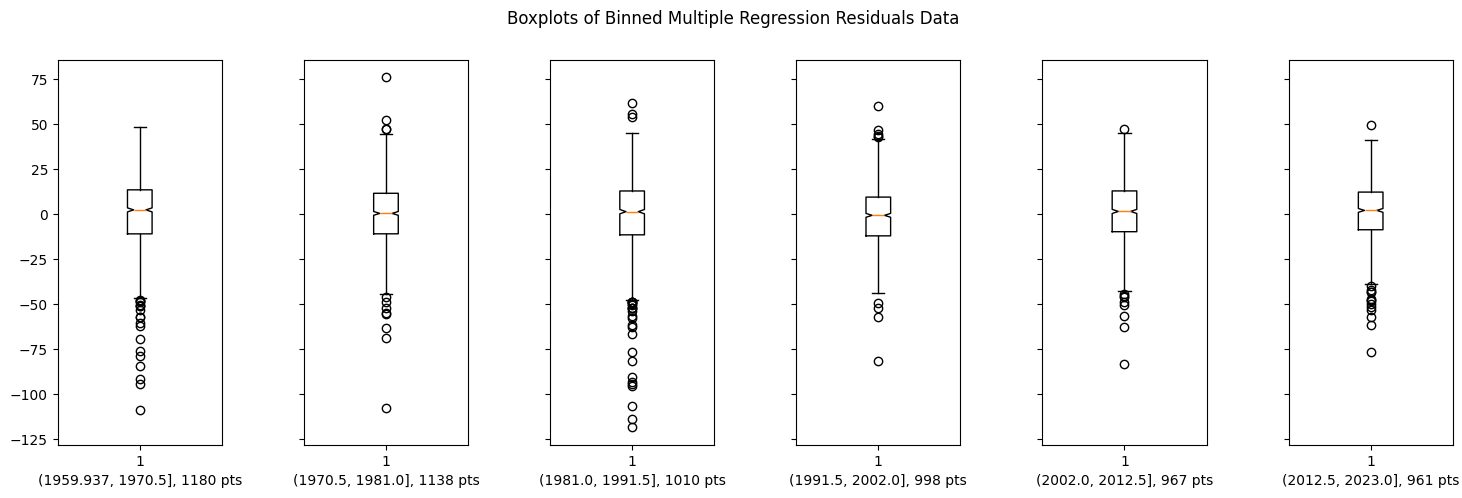

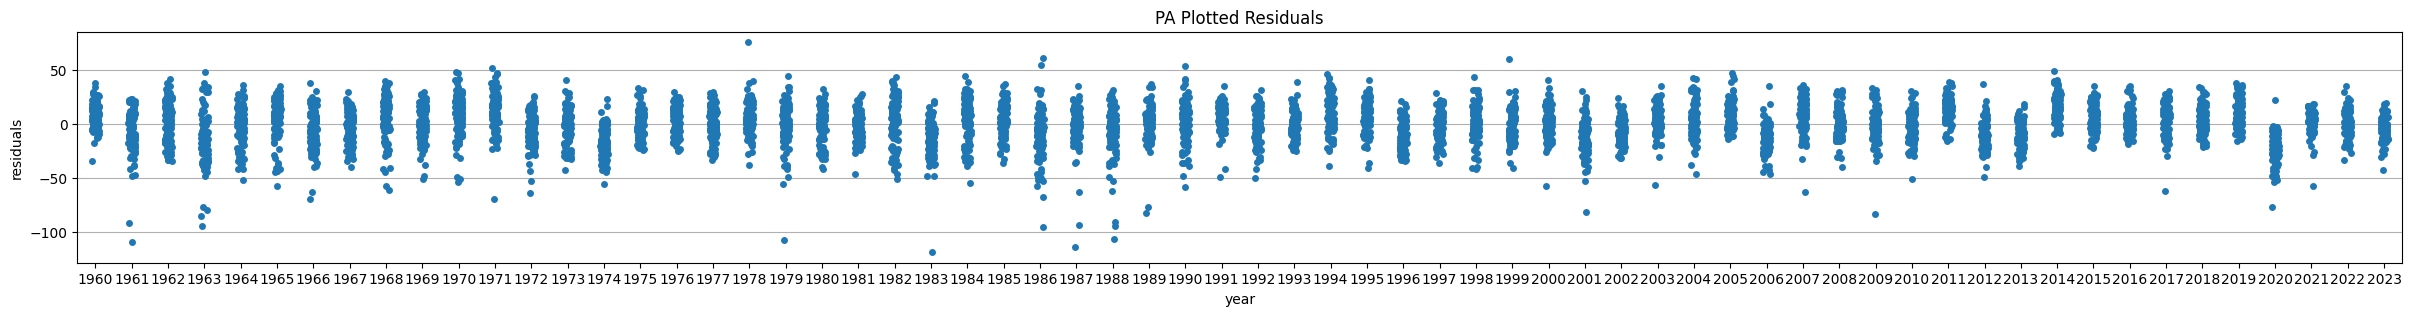

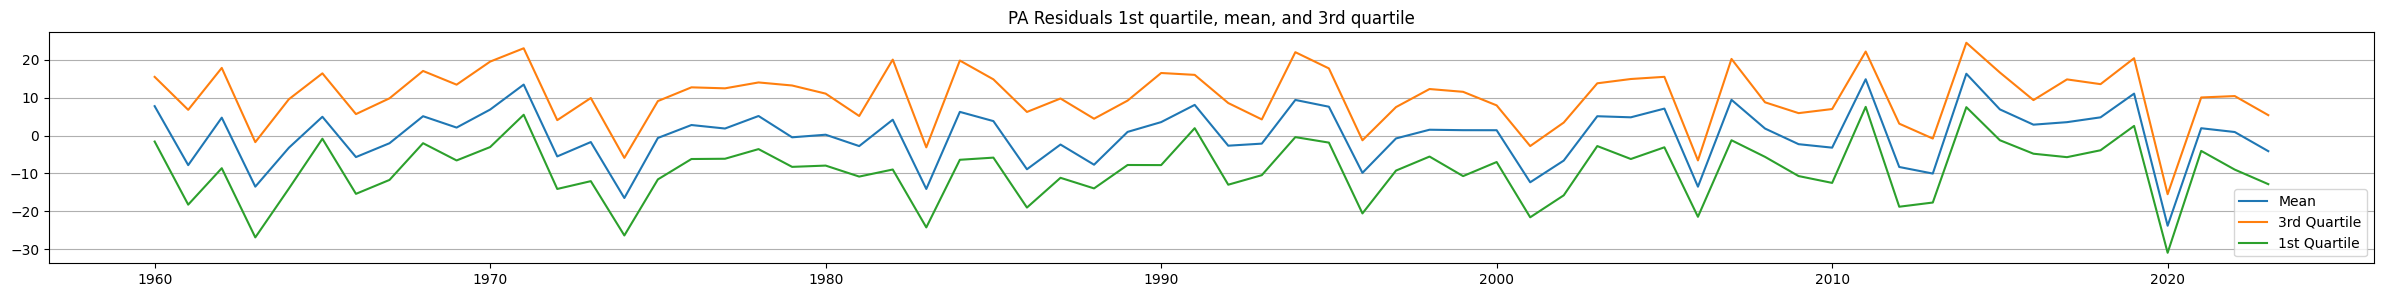

In [70]:
residuals_all = res_all.resid
res_df_all = residuals_all.to_frame()
res_df_all = pd.concat([res_df_all, Z_all], axis=1)
res_df_all.columns = ['residuals', 'year', 'station_name']

res_df_all['bins'] = pd.cut(x= res_df_all['year'], bins = 6)
res_df_all = res_df_all.sort_values(by='bins')


fig, axs = plt.subplots(1,6, sharey=True, figsize = (18, 5))
fig.suptitle('Boxplots of Binned Multiple Regression Residuals Data')
fig.subplots_adjust(wspace = 0.5)
n = 0
for value in res_df_all['bins'].unique():
    res_df_bin_all = res_df_all[res_df_all['bins'] == value]
    axs[n].boxplot(res_df_bin_all['residuals'], notch = True)
    axs[n].set_xlabel(f'{value}, {len(res_df_bin_all)} pts')
    n = n + 1
plt.show()

res_df_all_mean = res_df_all.groupby('year')['residuals'].mean()
res_df_all_mean = res_df_all_mean.to_frame()
res_df_all_mean = res_df_all_mean.reset_index()
res_df_all_mean.columns = ['year', 'residual_mean']

res_df_all_3q = res_df_all.groupby('year')['residuals'].quantile(0.75)
res_df_all_3q = res_df_all_3q.to_frame()
res_df_all_3q = res_df_all_3q.reset_index()
res_df_all_3q.columns = ['year', 'residual_3q']

res_df_all_1q = res_df_all.groupby('year')['residuals'].quantile(0.25)
res_df_all_1q = res_df_all_1q.to_frame()
res_df_all_1q = res_df_all_1q.reset_index()
res_df_all_1q.columns = ['year', 'residual_1q']

fig= plt.figure(figsize = (30,3))
fig = sns.stripplot(data = res_df_all, x = 'year', y = 'residuals')       
plt.grid(axis='y')
plt.title('PA Plotted Residuals')
plt.show

fig= plt.figure(figsize = (30,3))
fig = plt.plot(res_df_all_mean['year'], res_df_all_mean['residual_mean'], label = 'Mean')
fig = plt.plot(res_df_all_3q['year'], res_df_all_3q['residual_3q'], label = '3rd Quartile')
fig = plt.plot(res_df_all_1q['year'], res_df_all_1q['residual_1q'], label = '1st Quartile')
plt.grid(axis='y')
plt.title('PA Residuals 1st quartile, mean, and 3rd quartile')
plt.legend()
plt.show()

Am I going crazy, or is there a periodic cycle happening in the IQR from ~1980 or ~1985 to the present?

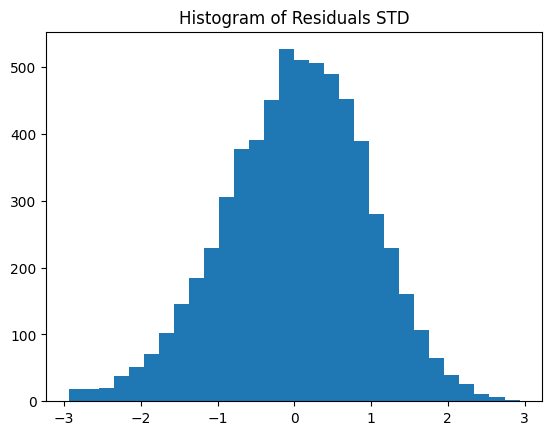

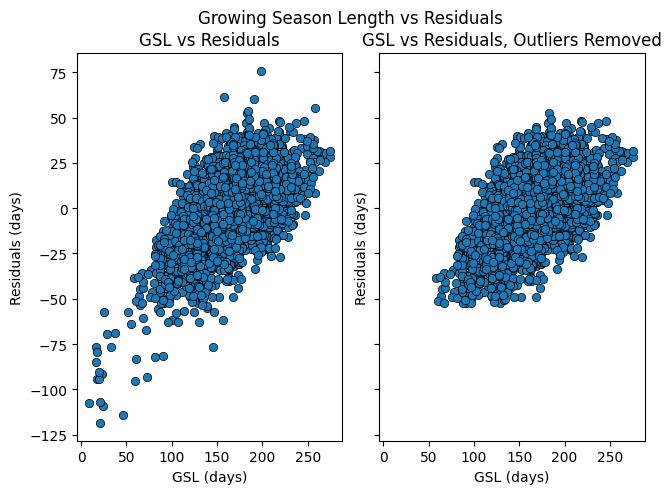

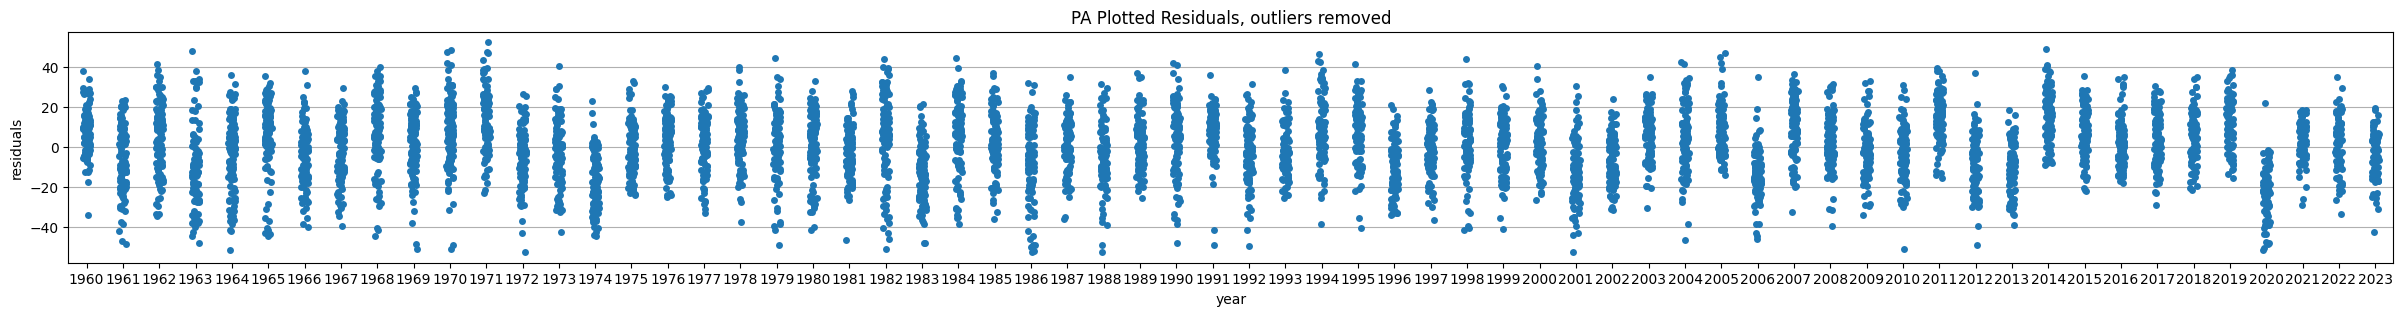

In [81]:
resid_std_val = res_df_all['residuals'].std()
resid_std = res_df_all['residuals'] / resid_std_val
res_df_std = pd.concat([res_df_all,resid_std, y_all], axis = 1)
res_df_std.columns = ['residuals', 'year', 'station_name', 'bins', 'residuals_STD', 'growing_season_length']

res_df_std = res_df_std[res_df_std['residuals_STD'].between(-3, 3)]

fig = plt.hist(res_df_std['residuals_STD'], bins = 30)
plt.title('Histogram of Residuals STD')
plt.show()

res_df_all_gs = pd.concat([res_df_all, y_all], axis = 1)

fig, axs = plt.subplots(1,2, sharey=True, sharex=True)
fig.suptitle('Growing Season Length vs Residuals')
fig.tight_layout()
axs[0].scatter(data = res_df_all_gs, x = 'growing_season_length', y = 'residuals', edgecolors = 'black', linewidths = 0.5)
axs[0].set_title('GSL vs Residuals')
axs[0].set_xlabel('GSL (days)')
axs[0].set_ylabel('Residuals (days)')
axs[1].scatter(data = res_df_std, x = 'growing_season_length', y = 'residuals', edgecolors = 'black', linewidths = 0.5)
axs[1].set_title('GSL vs Residuals, Outliers Removed')
axs[1].set_xlabel('GSL (days)')
axs[1].set_ylabel('Residuals (days)')
plt.show()

fig= plt.figure(figsize = (30,3))
fig = sns.stripplot(data = res_df_std, x = 'year', y = 'residuals')       
plt.grid(axis='y')
plt.title('PA Plotted Residuals, outliers removed')
plt.show()

### Heteroscedasticity by Station

In [48]:
def station_residuals_plotting(station_name, bin_no):
    X_s, y_s, Z_s = remove_nulls_ext(pa_gs[pa_gs['station_name'] == station_name], X, y, Z)
    X_s= sm.add_constant(X_s)
                 
    mod_s = sm.OLS(y_s, X_s)
    res_s = mod_s.fit()
    #print(res_s.summary())
    
    residuals_s = res_s.resid
    res_df_s = residuals_s.to_frame()
    res_df_s = pd.concat([res_df_s, Z_s], axis=1)
    res_df_s.columns = ['residuals', 'year']
    
    res_df_s['bins'] = pd.cut(x= res_df_s['year'], bins = bin_no)
    res_df_s = res_df_s.sort_values(by='bins')
    
    
    fig, axs = plt.subplots(1,bin_no, sharey=True, figsize = (bin_no * 2, 5))
    fig.suptitle(f'Boxplots of Binned Multiple Regression Residuals Data for {station_name}, PA')
    fig.subplots_adjust(wspace = bin_no * 3/5)
    n = 0
    for value in res_df_s['bins'].unique():
        res_df_bin = res_df_s[res_df_s['bins'] == value]
        axs[n].boxplot(res_df_bin['residuals'], notch= True)
        axs[n].set_xlabel(f'{value}, {len(res_df_bin)} pts')
        n = n + 1
    plt.show()

    fig = plt.figure(figsize = (30,3))
    fig = sns.stripplot(data = res_df_s, x = 'year', y = 'residuals')
    plt.grid(axis='y')
    plt.title(f'Plotted Residuals for {station_name}')
    plt.show()

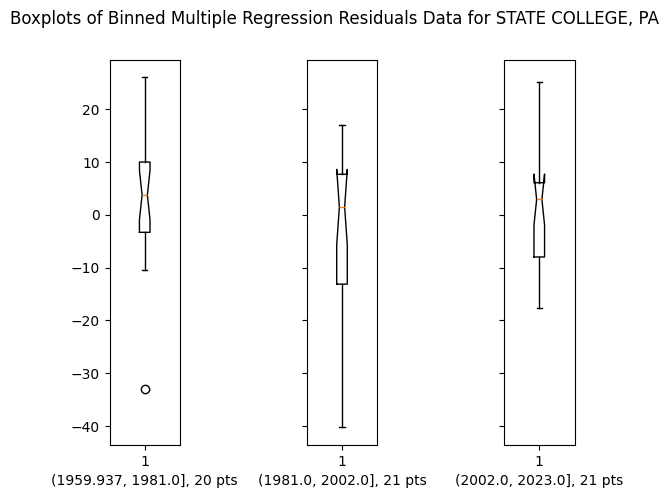

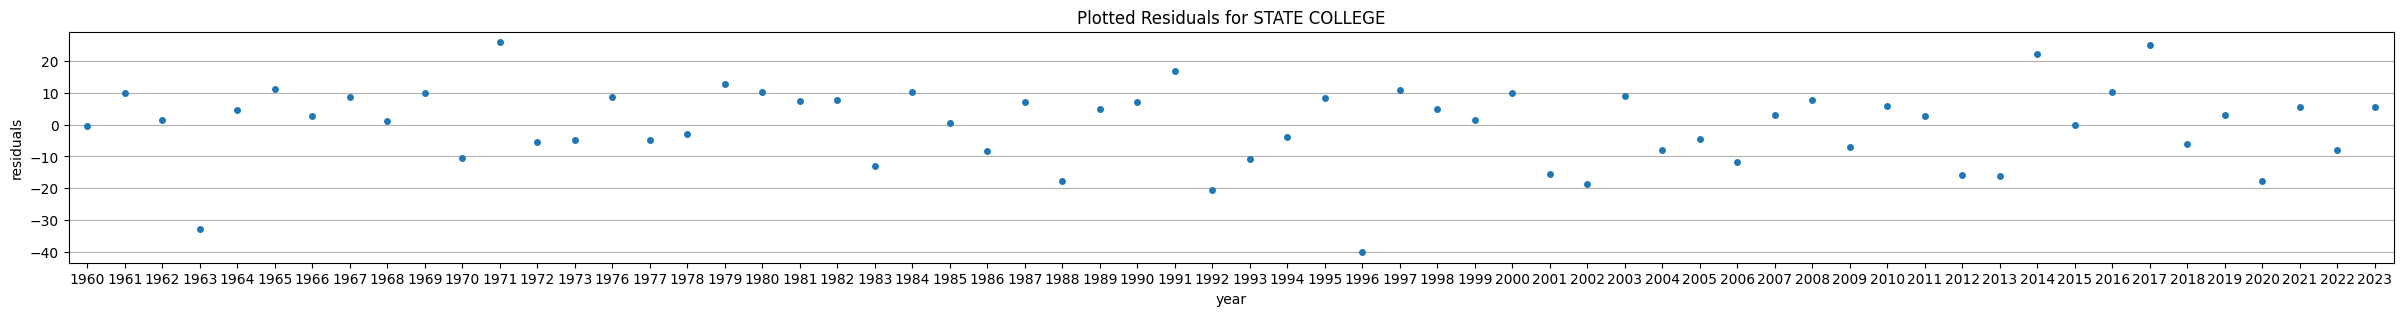

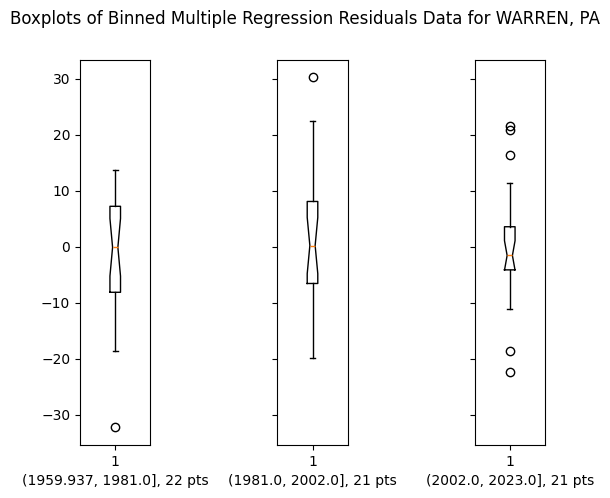

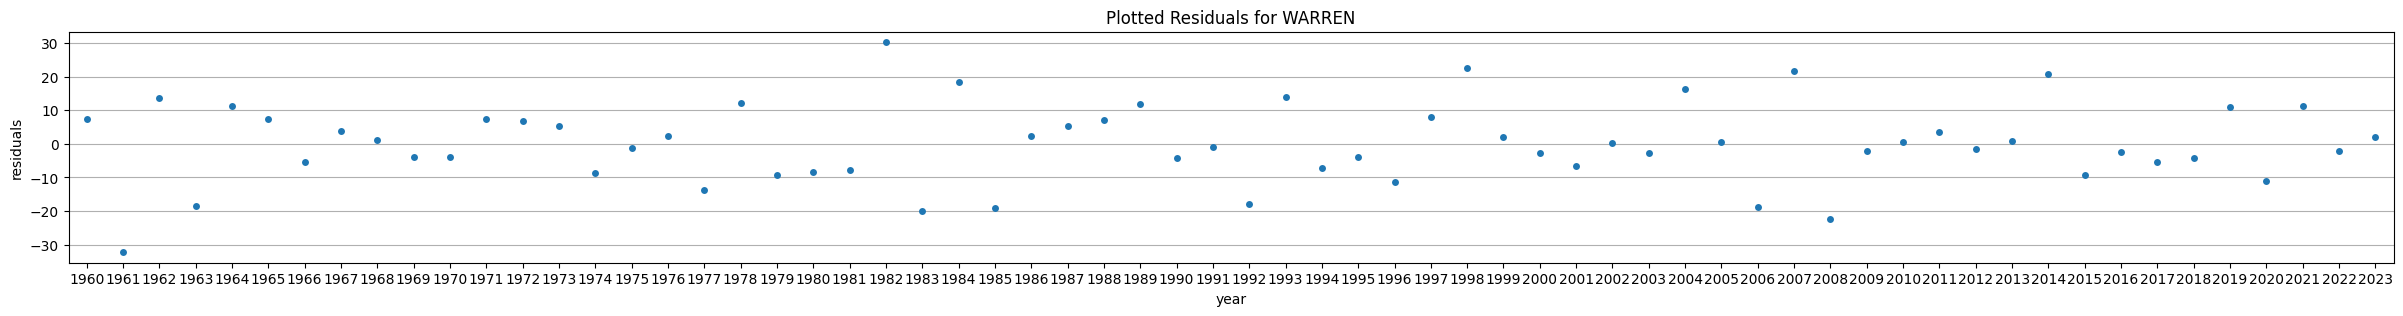

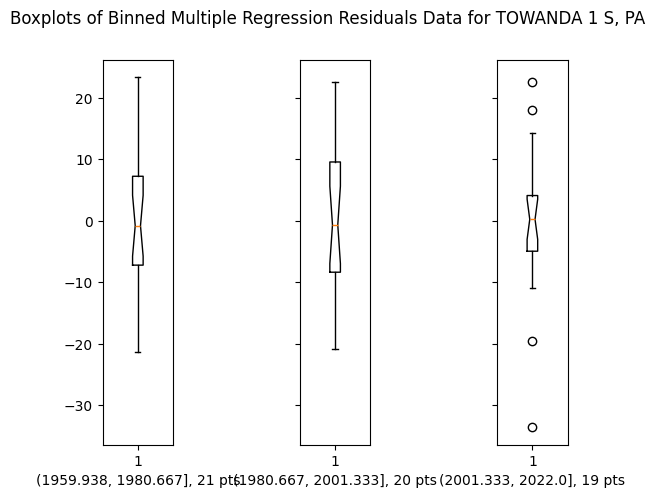

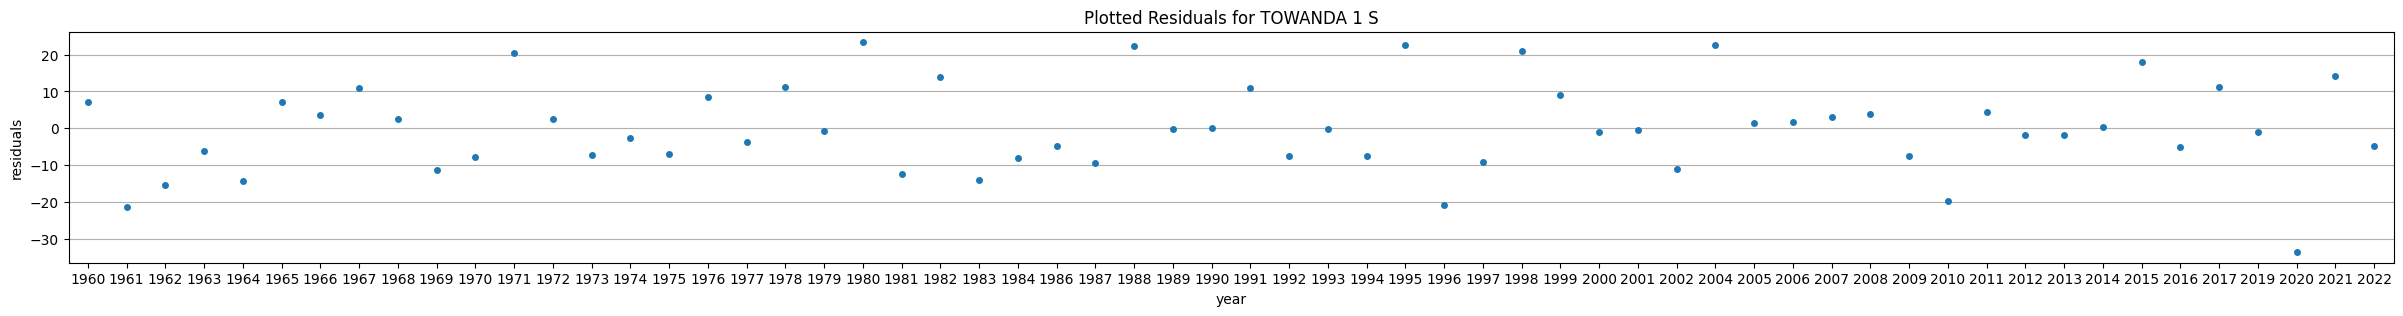

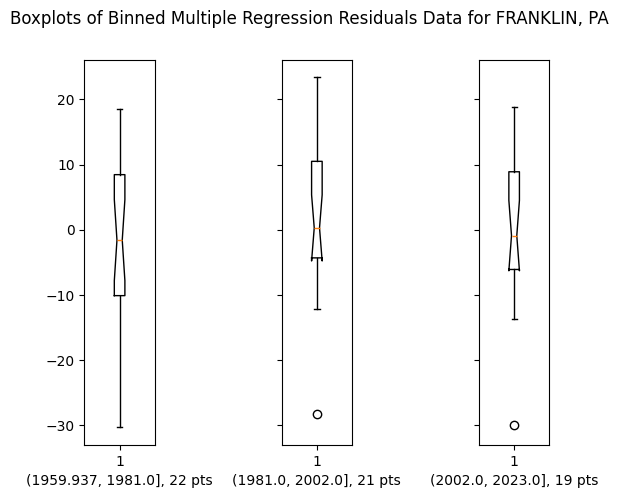

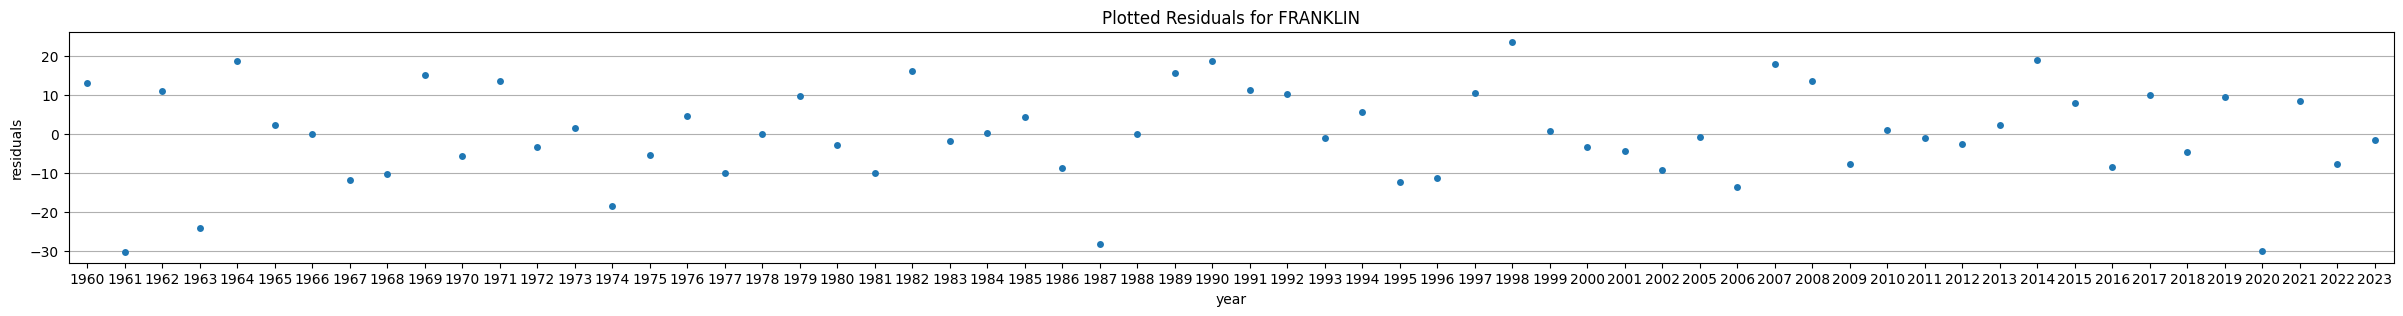

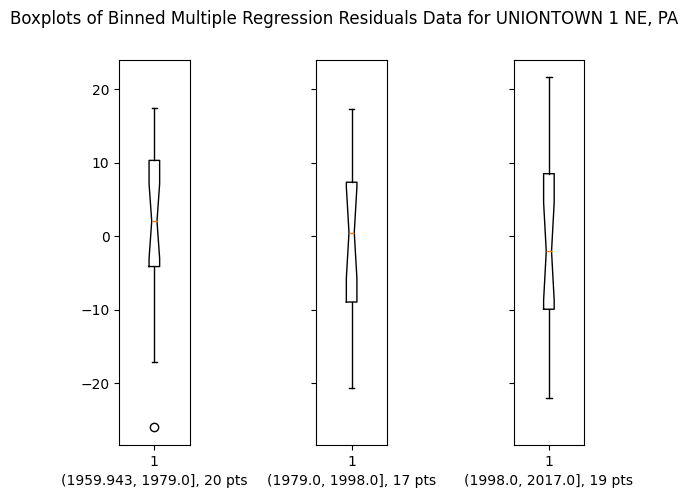

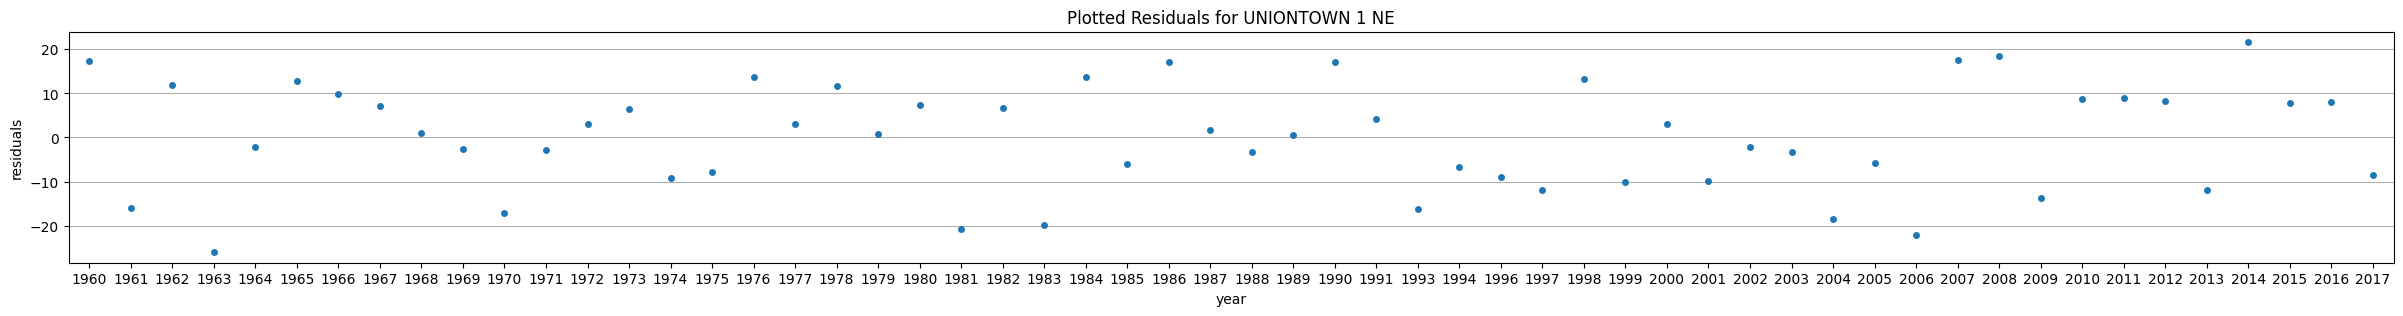

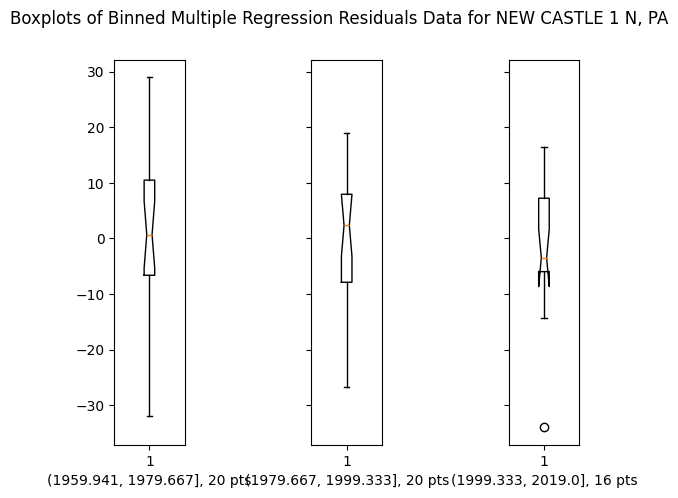

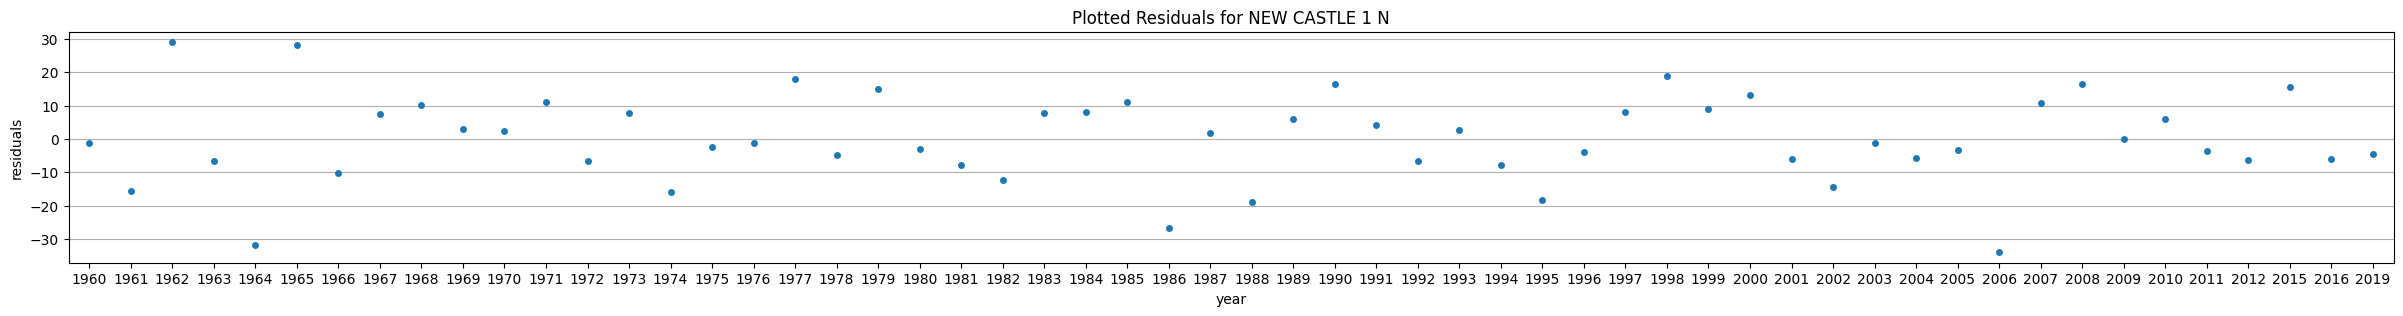

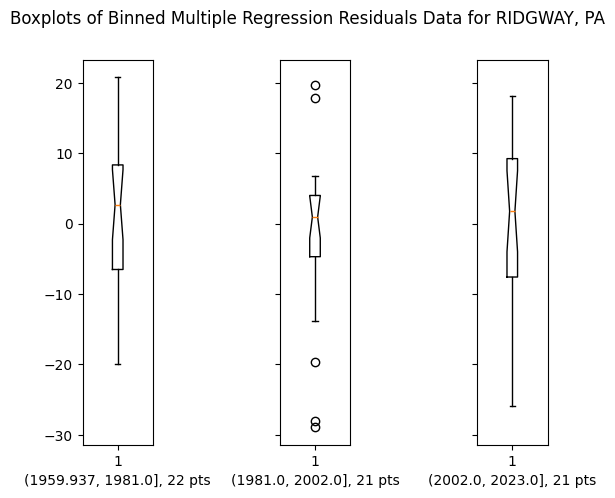

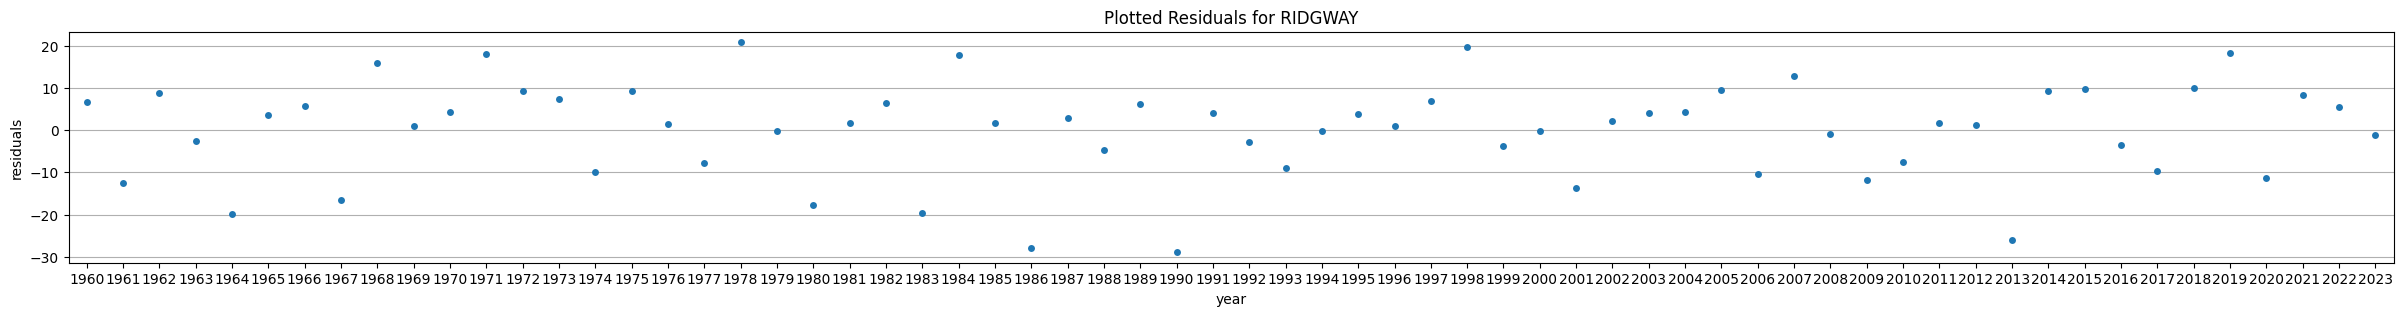

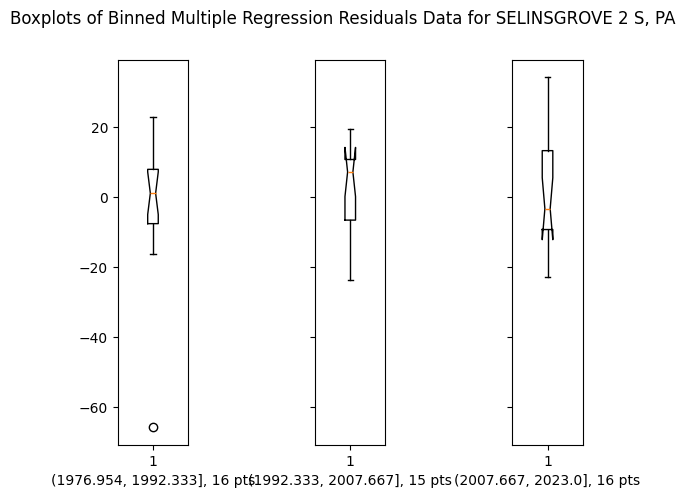

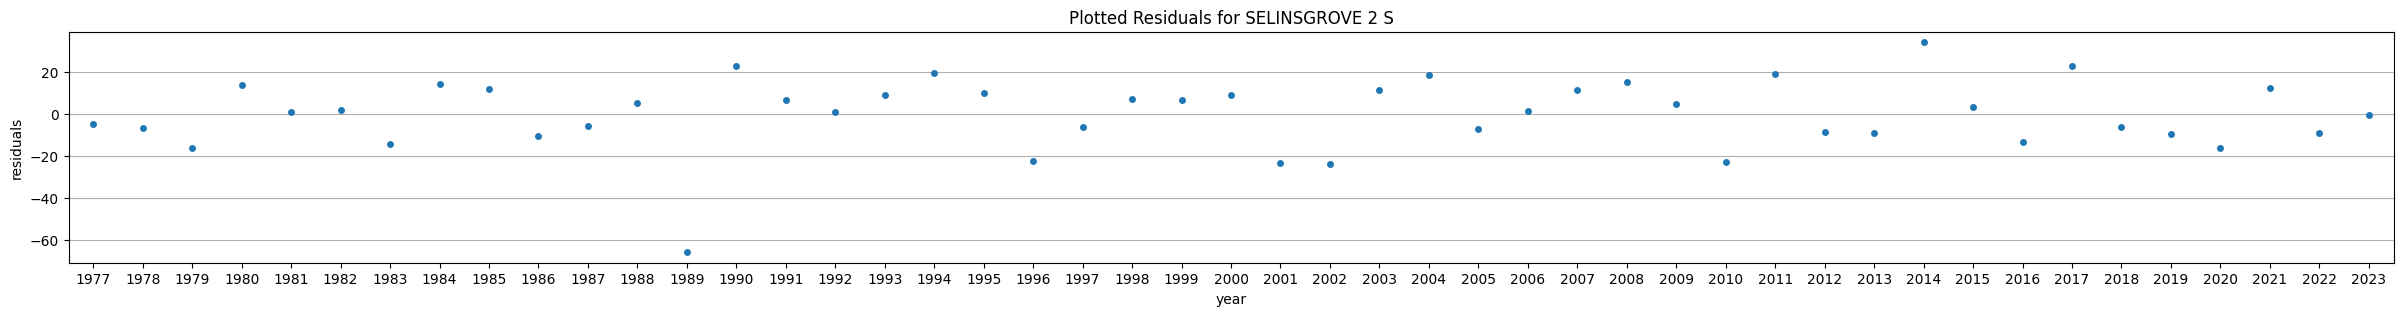

In [49]:
top_stations = ['STATE COLLEGE', 'WARREN', 'TOWANDA 1 S', 'FRANKLIN', 'UNIONTOWN 1 NE', 
                'NEW CASTLE 1 N', 'RIDGWAY', 'SELINSGROVE 2 S']
for station in top_stations:
    station_residuals_plotting(station, 3)

## Heteroscedasticity by Subset

In [50]:
def subset_residuals_plotting(subset, subset_name, bin_no):
    X_s, y_s, Z_s = remove_nulls_ext(subset, X, y, Z)
    X_s= sm.add_constant(X_s)
                 
    mod_s = sm.OLS(y_s, X_s)
    res_s = mod_s.fit()
    #print(res_s.summary())
    
    residuals_s = res_s.resid
    res_df_s = residuals_s.to_frame()
    res_df_s = pd.concat([res_df_s, Z_s], axis=1)
    res_df_s.columns = ['residuals', 'year']
    
    res_df_s['bins'] = pd.cut(x= res_df_s['year'], bins = bin_no)
    res_df_s = res_df_s.sort_values(by='bins')
    
    
    fig, axs = plt.subplots(1,bin_no, sharey=True, figsize = (bin_no * 2, 5))
    fig.suptitle(f'Boxplots of Binned Multiple Regression Residuals Data for {subset_name} PA')
    fig.subplots_adjust(wspace = bin_no * 3/5)
    n = 0
    for value in res_df_s['bins'].unique():
        res_df_bin = res_df_s[res_df_s['bins'] == value]
        axs[n].boxplot(res_df_bin['residuals'], notch= True)
        axs[n].set_xlabel(f'{value}, {len(res_df_bin)} pts')
        n = n + 1
    plt.show()

    fig = plt.figure(figsize = (30, 3))
    fig = sns.stripplot(data = res_df_s, x = 'year', y = 'residuals')
    plt.grid(axis='y')
    plt.title(f'Plotted Residuals for {subset_name} PA')
    plt.show()

coastal_pa_stations = pa_gs[pa_gs['dist_atlantic_km']< 150]
lakeside_pa_stations = pa_gs[pa_gs['dist_greatlakes_km']< 150]
inland_pa_stations = pa_gs[pa_gs['dist_coast_km']>150]
east_pa_stations = pa_gs[pa_gs['longitude'] < -77.569]
west_pa_stations = pa_gs[pa_gs['longitude'] > -77.569]
north_pa_stations = pa_gs[pa_gs['latitude'] > 40.58]
south_pa_stations = pa_gs[pa_gs['latitude'] < 40.58]
low_elevation_pa_stations = pa_gs[pa_gs['elevation_m'] > 371.9]
high_elevation_pa_stations = pa_gs[pa_gs['elevation_m'] <139.9]

subsets = {'Coastal': coastal_pa_stations, 'Lakeside': lakeside_pa_stations, 'Inland': inland_pa_stations,
           'Eastern': east_pa_stations, 'Western': west_pa_stations, 'Northern': north_pa_stations, 'Southern': south_pa_stations,
           'Low Elevation': low_elevation_pa_stations, 'High Elevation': high_elevation_pa_stations}

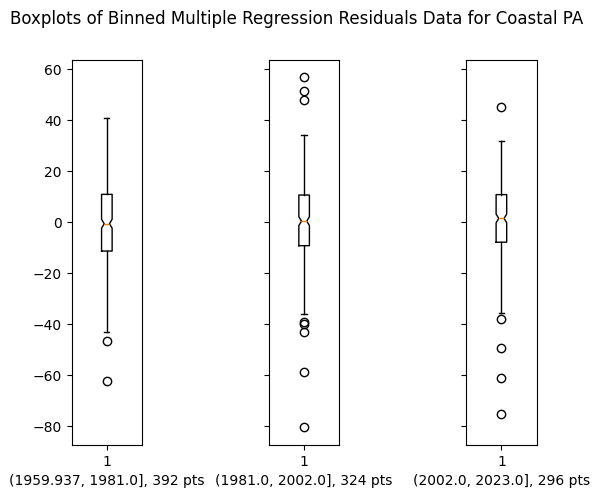

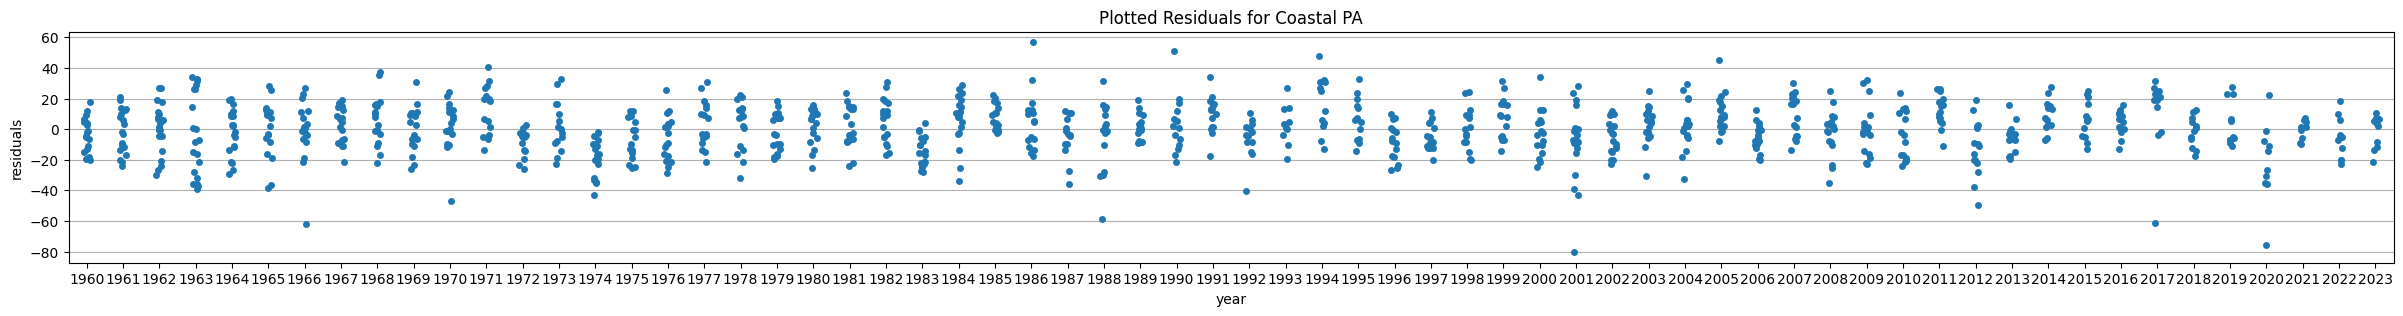

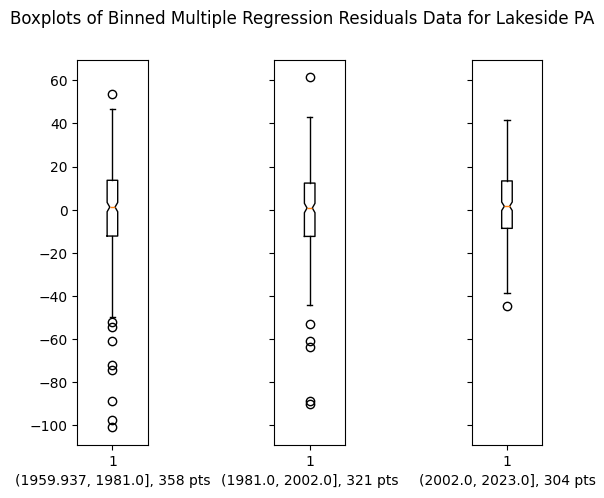

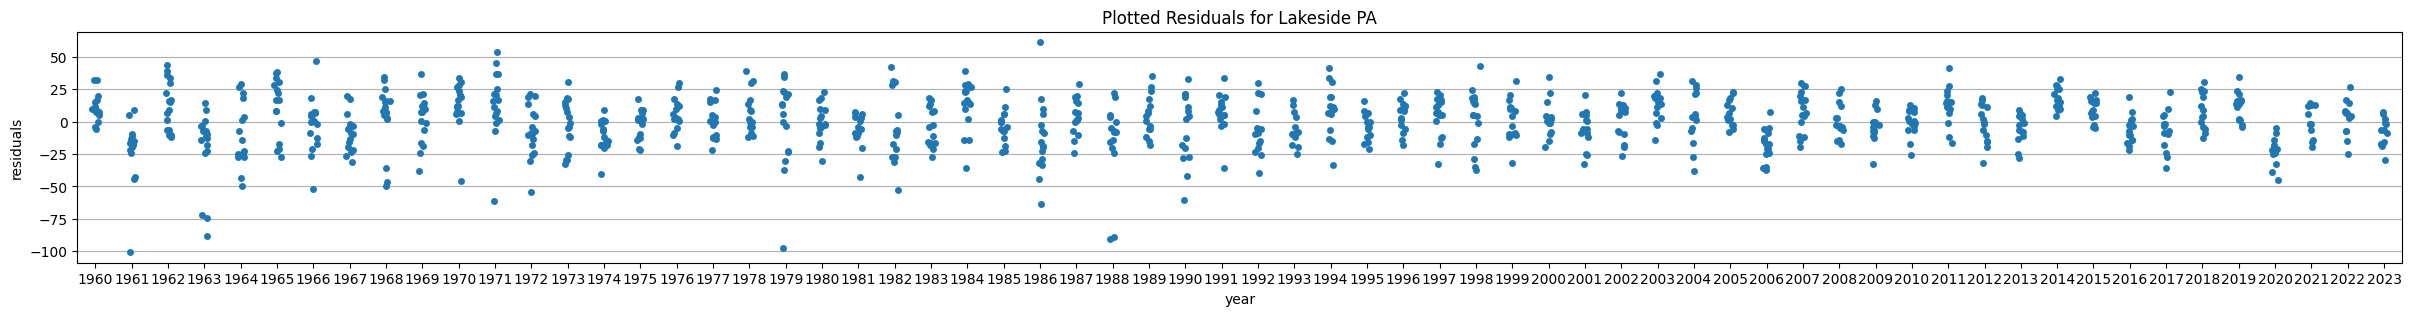

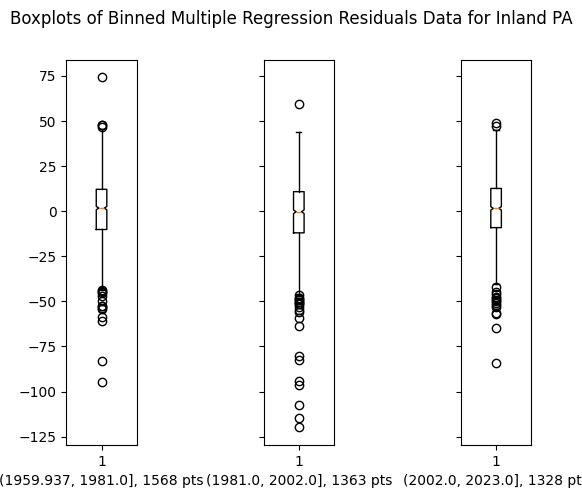

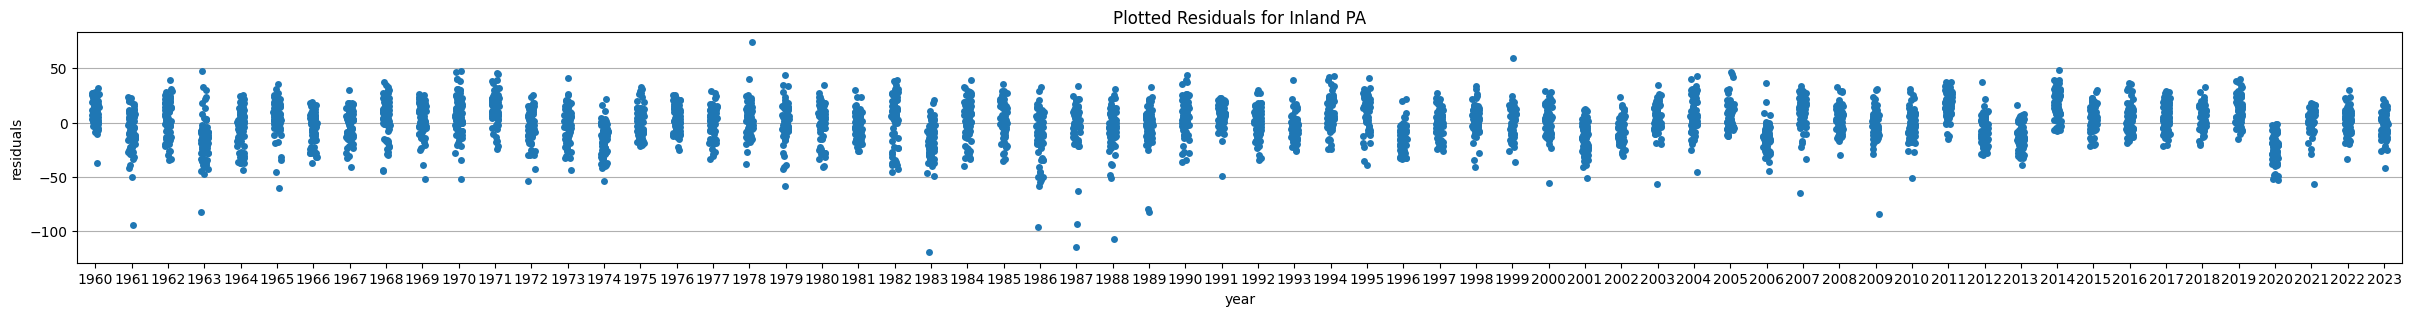

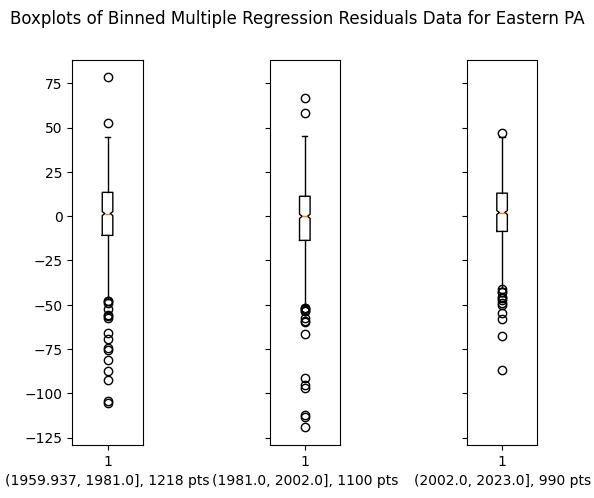

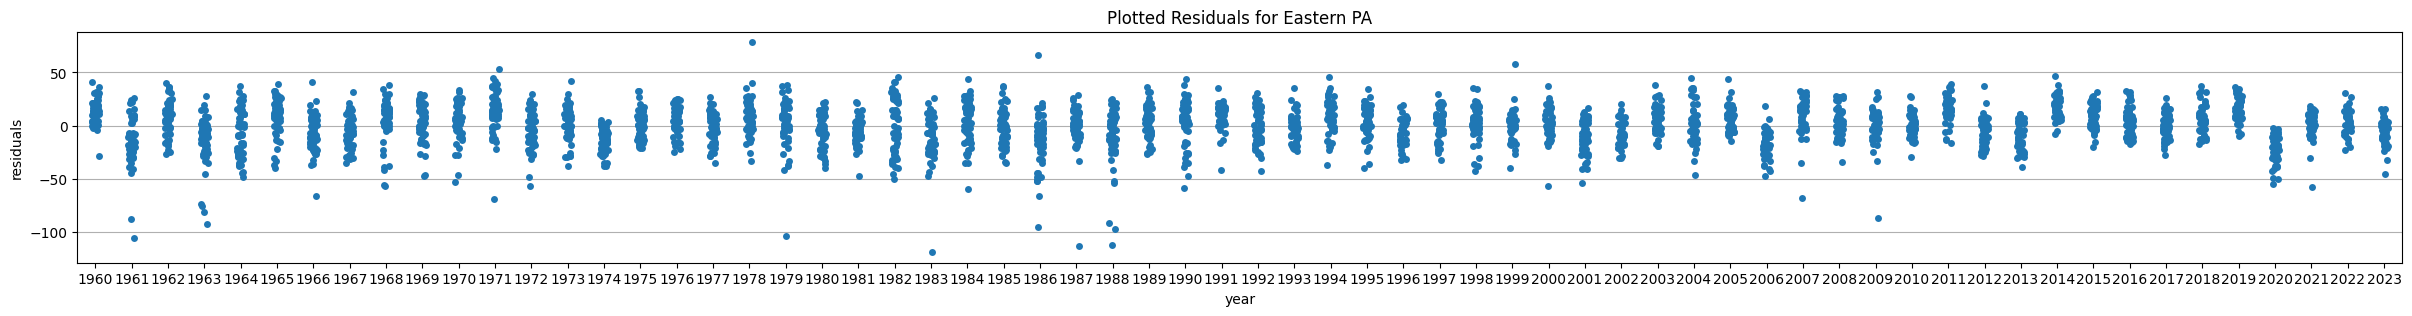

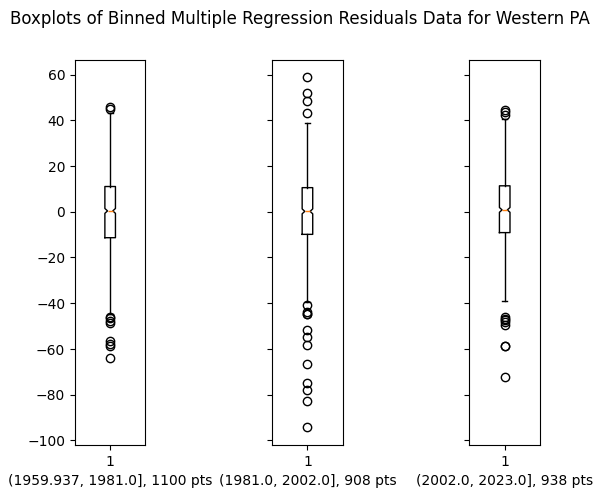

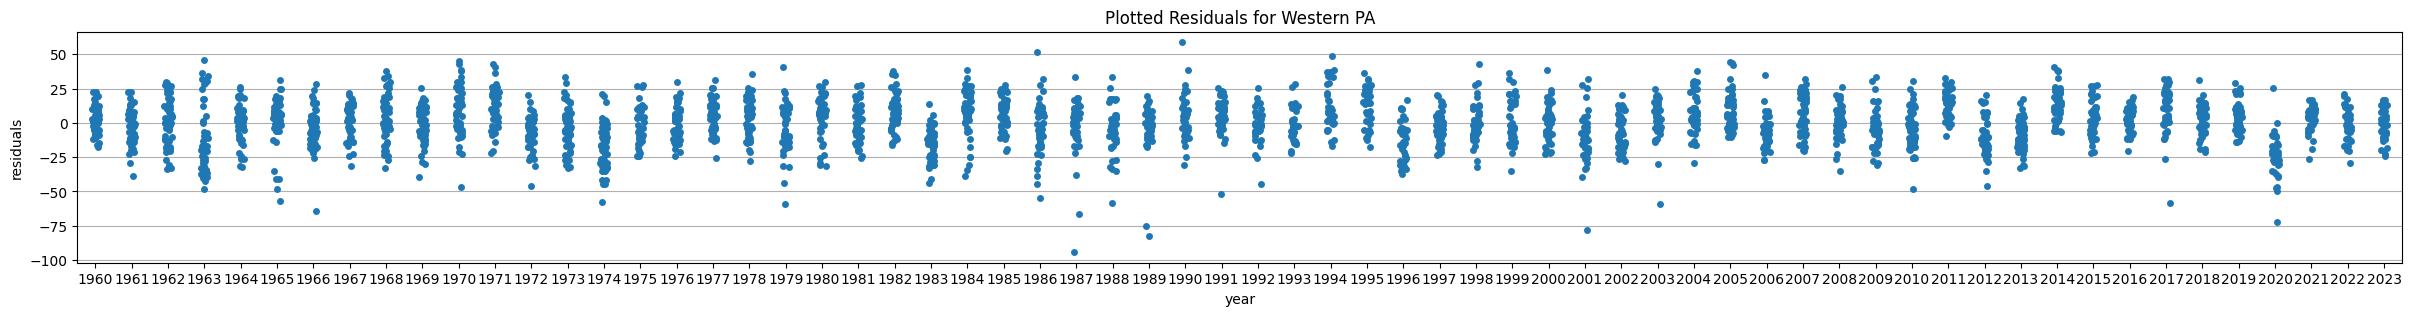

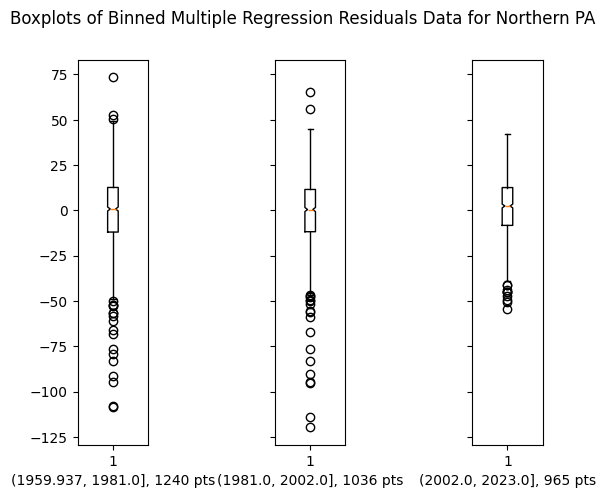

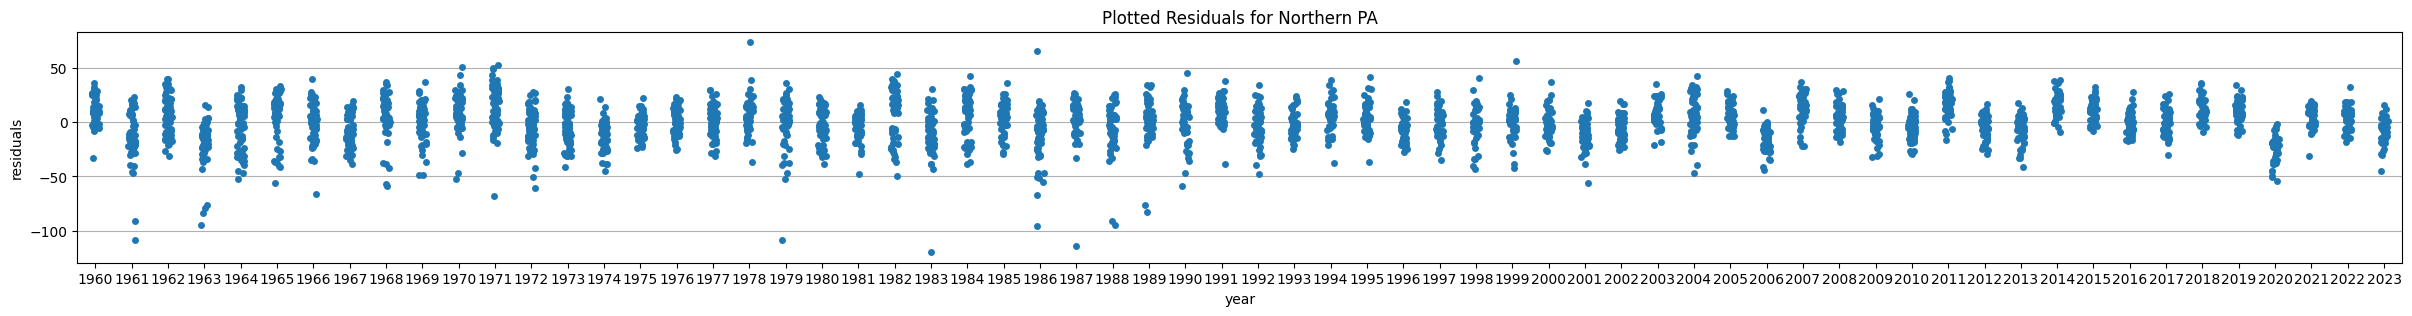

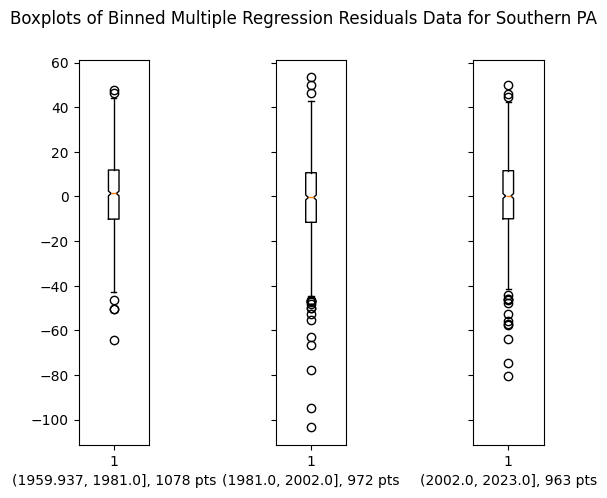

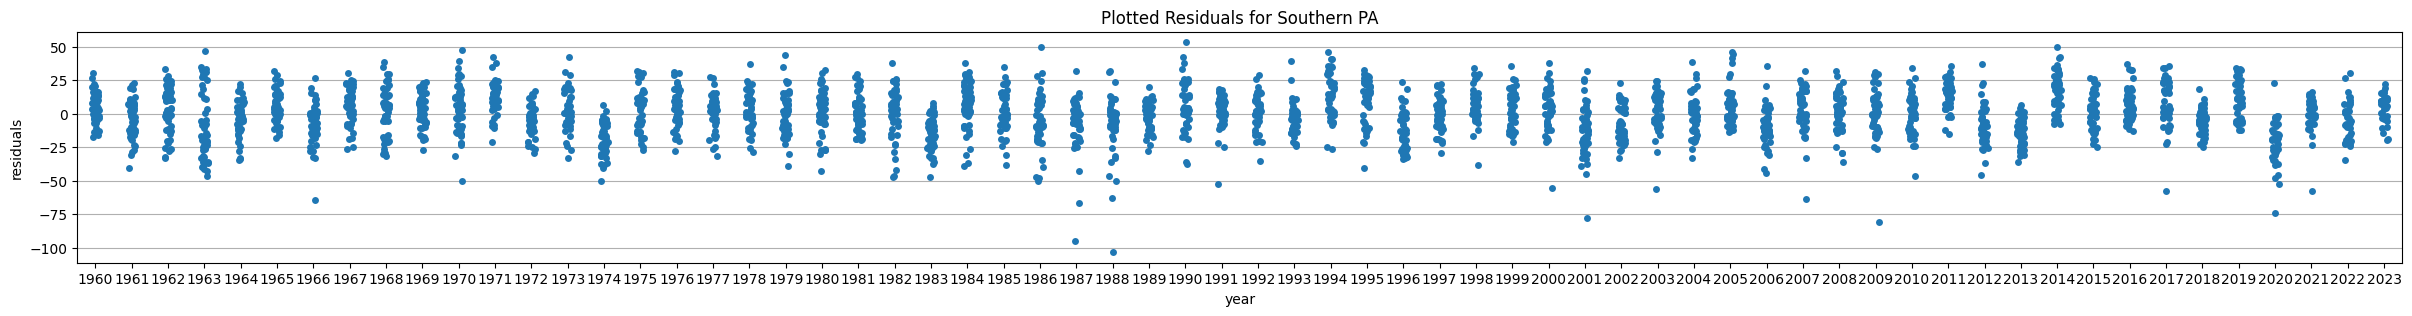

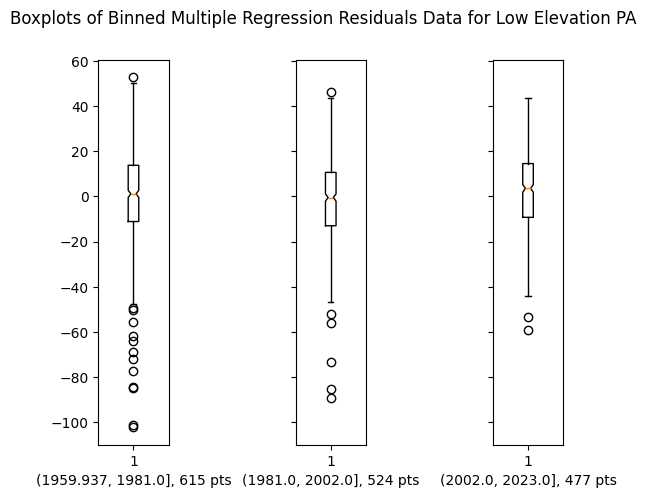

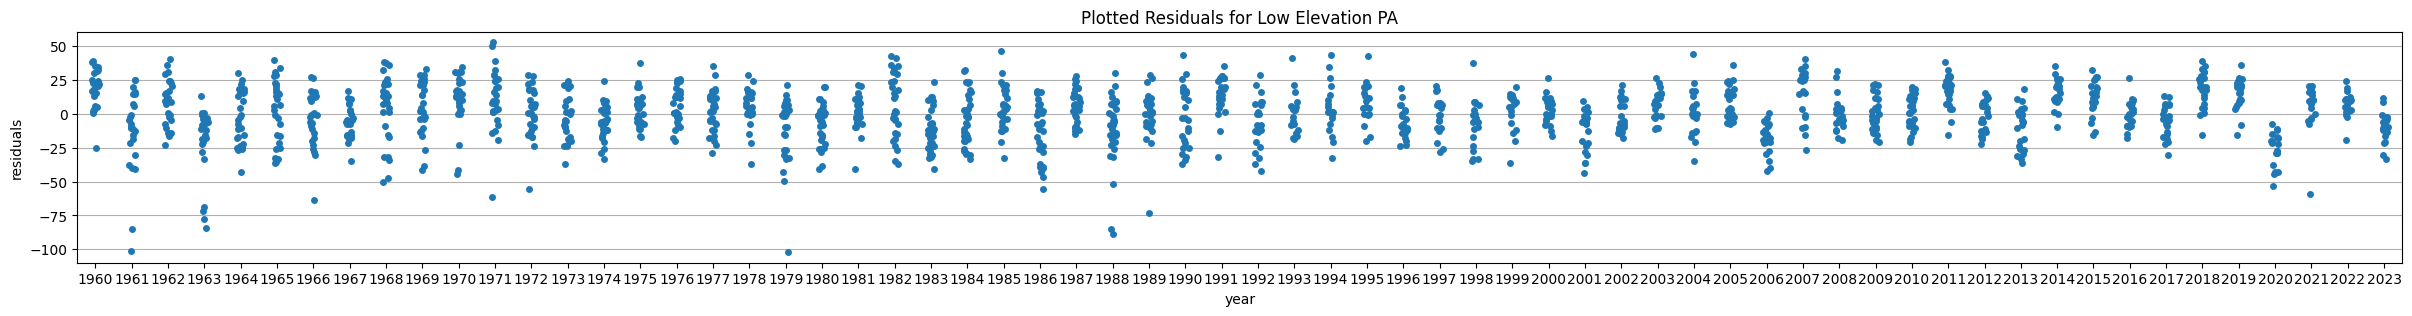

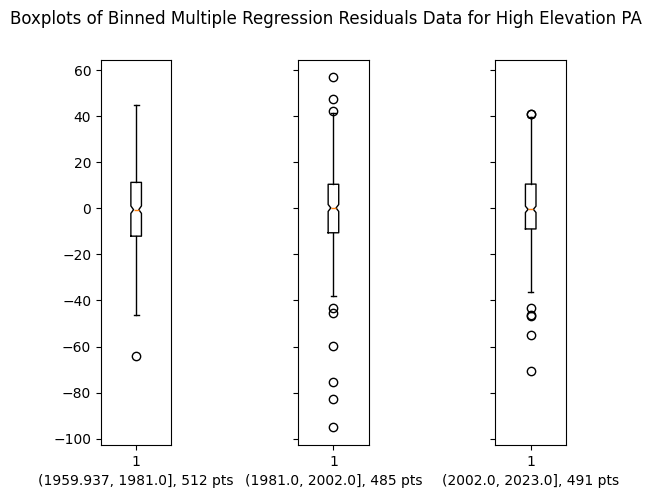

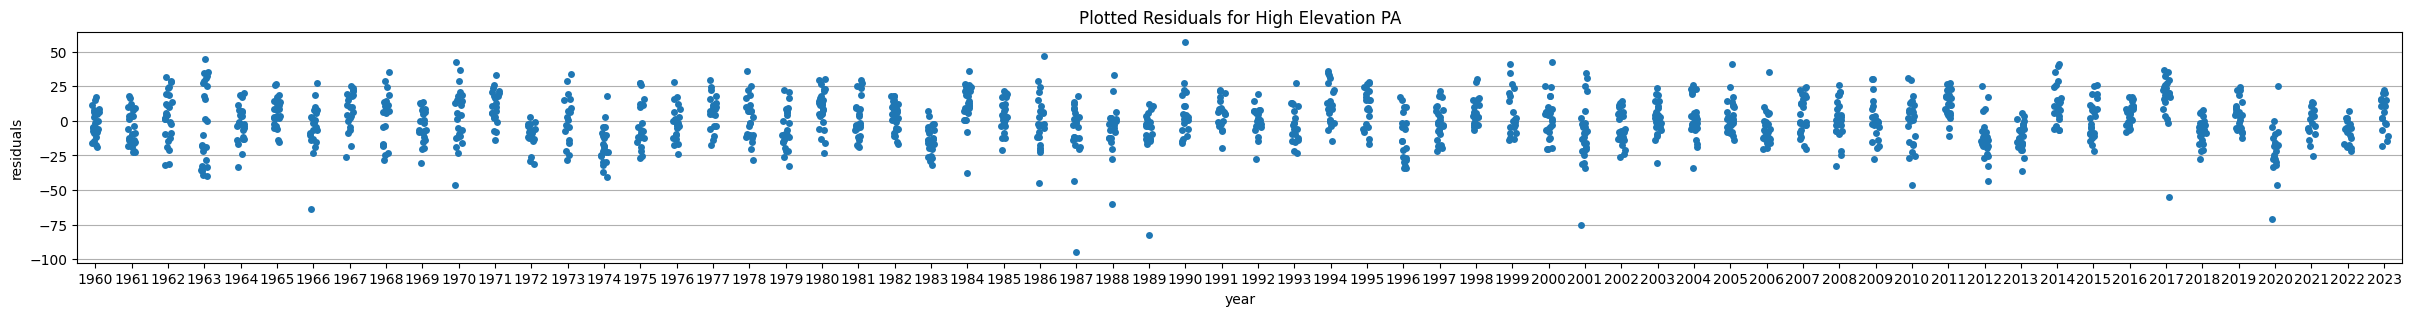

In [51]:
for subset_name, subset in subsets.items():
    subset_residuals_plotting(subset, subset_name, 3)

There are certain graphs of plotted residuals below which appear to show a similar cycle to the strip plot of the entire state's residuals by year. The subsets that most noticeably show this cycle are:
* Western
* Southern
* High Elevation

### Fligner-Kileen Testing

In [30]:
from scipy.stats import fligner
def subset_residuals_fligner(subset, subset_name, bin_no):
    X_s, y_s, Z_s = remove_nulls_ext(subset, X, y, Z)
    X_s= sm.add_constant(X_s)
                 
    mod_s = sm.OLS(y_s, X_s)
    res_s = mod_s.fit()
    #print(res_s.summary())
    
    residuals_s = res_s.resid
    res_df_s = residuals_s.to_frame()
    res_df_s = pd.concat([res_df_s, Z_s], axis=1)
    res_df_s.columns = ['residuals', 'year']
    
    res_df_s['bins'] = pd.cut(x= res_df_s['year'], bins = bin_no)
    res_df_s = res_df_s.sort_values(by='bins')
    
    sample = []
    for value in res_df_s['bins'].unique():
        bin_val = res_df_s[res_df_s['bins'] == value]
        bin_val = bin_val['residuals'].to_numpy()
        sample.append(bin_val)
    stat, p_val = fligner(*sample, center = 'mean')
    print(f'{subset_name} : Stat = {stat}, P-Value = {p_val}')

In [31]:
subset_residuals_fligner(pa_gs, 'PA', 6)

PA : Stat = 47.208475679208235, P-Value = 5.151740286868077e-09


For the entire state of PA, the Fligner-Killeen test is successful in rejecting the null hypothesis of no significant change in variance and determines that across the 6 bins created, there is significant change to the variance of the residuals in the GSL model.

In [32]:
for subset_name, subset in subsets.items():
    subset_residuals_fligner(subset, subset_name, 3)

Coastal : Stat = 2.742373446459736, P-Value = 0.25380558378121165
Lakeside : Stat = 11.16355895186315, P-Value = 0.003765858298689481
Inland : Stat = 4.703200516654308, P-Value = 0.09521666896639878
Eastern : Stat = 10.64665171772033, P-Value = 0.004876508147136537
Western : Stat = 7.6164864093873215, P-Value = 0.022187122972188333
Northern : Stat = 17.858801431422542, P-Value = 0.00013243736838692072
Southern : Stat = 1.509840284234097, P-Value = 0.47004815028193003
Low Elevation : Stat = 4.89923167990151, P-Value = 0.08632674341618328
High Elevation : Stat = 6.617810562480998, P-Value = 0.03655617058281899


Fligner rejects null hypothesis and determines that there is significant change to variance of residuals of the GSL model for the following subsets:
* PA (whole)
* Lakeside
* Eastern
* Western
* Northern
* High Elevation

Fligner fails to reject null hypothesis and cannot determine if change to variance is significant for following subsets:
* Coastal
* Inland
* Southern
* Low Elevation